In [2]:
pip install contextily

In [3]:
# packages
from google.colab import files
import io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
import contextily as ctx
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

In [4]:
## Read in SOPP Dataset
file_path = '/content/sopp_df.csv'
sopp_df = pd.read_csv(file_path)
selection = ["moving traffic violation", "seatbelt violaton"]
sopp_df = sopp_df[sopp_df["reason_for_stop"].isin(selection)]

/tmp/ipykernel_11239/1311564429.py:3: DtypeWarning: Columns (7,9,16,17,18,23,24,25,26,30,31,32,33,34,36,37,38,39,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  sopp_df = pd.read_csv(file_path)


In [5]:
# read in crash dataset
file_path = '/content/crash_df.csv'
crash_df = pd.read_csv(file_path)

In [ ]:
gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

x = gdf_web_mercator.geometry.x
y = gdf_web_mercator.geometry.y

fig, ax = plt.subplots(figsize=(12, 12))

kde = sns.kdeplot(
    data=gdf_web_mercator,
    x=gdf_web_mercator.geometry.x,
    y=gdf_web_mercator.geometry.y,
    fill=True,
    cmap="Purples",
    levels=60,
    alpha=0.6,
    cbar=True,
    ax=ax
)

cbar = kde.collections[0].colorbar
cbar.set_label("Crash Density")
cbar.formatter.set_powerlimits((0,0))
cbar.update_ticks()

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Police Stop Density Heatmap", fontsize=18)
plt.tight_layout()

plt.show()

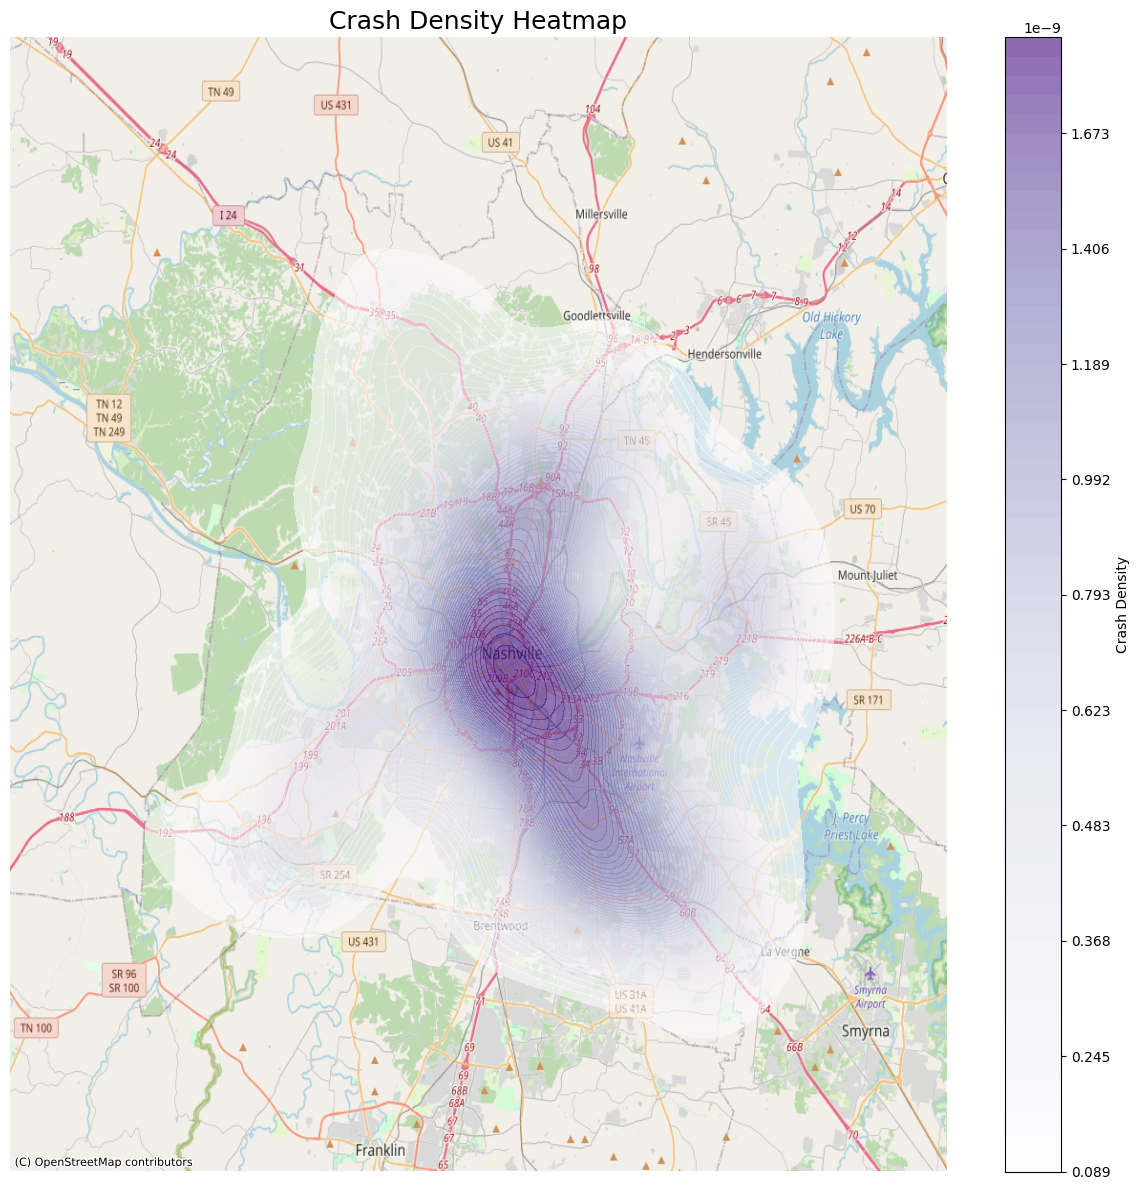

In [25]:
gdf = gpd.GeoDataFrame(
    crash_df,
    geometry=gpd.points_from_xy(crash_df.lng, crash_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

x = gdf_web_mercator.geometry.x
y = gdf_web_mercator.geometry.y

fig, ax = plt.subplots(figsize=(12, 12))

kde = sns.kdeplot(
    data=gdf_web_mercator,
    x=gdf_web_mercator.geometry.x,
    y=gdf_web_mercator.geometry.y,
    fill=True,
    cmap="Purples",
    levels=60,
    alpha=0.6,
    cbar=True,
    ax=ax
)

cbar = kde.collections[0].colorbar
cbar.set_label("Crash Density")
cbar.formatter.set_powerlimits((0,0))
cbar.update_ticks()

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Crash Density Heatmap", fontsize=18)
plt.tight_layout()

plt.show()

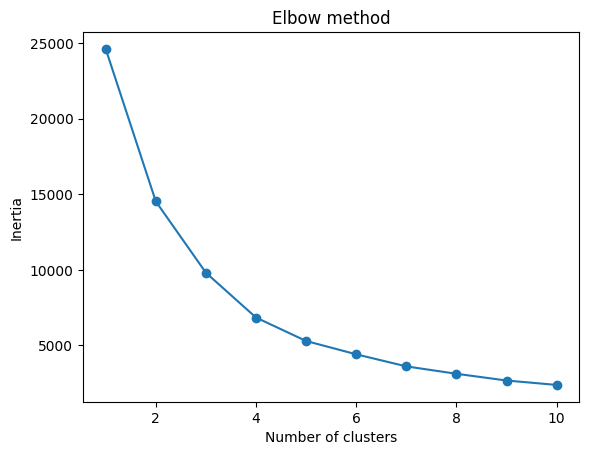

In [8]:
X = sopp_df[['lat', 'lng']].values

inertias = []
for i in range(1, 11):
    # 'k-means++' is an advanced initialization method that speeds up convergence
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # Get the SSE (inertia)

# Plot the elbow method graph
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [7]:
X = sopp_df[['lat', 'lng']].values

In [8]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10) #

# Fit the model to the data and predict the cluster assignments
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels back to your DataFrame
sopp_df['cluster_label'] = y_kmeans


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


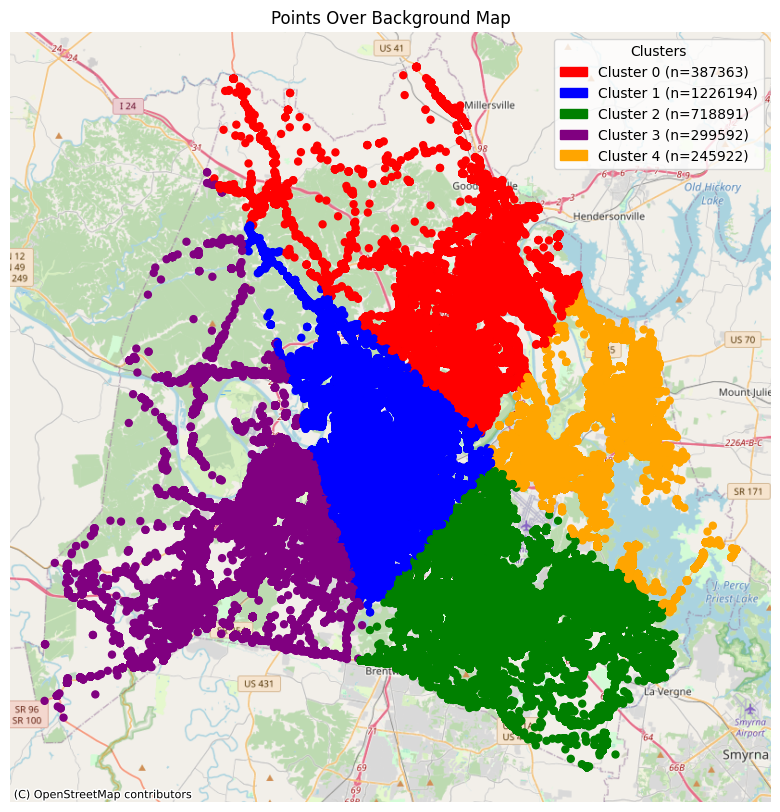

In [10]:
color_map = {
    0: "red",
    1: "blue",
    2: "green",
    3: "purple",
    4: "orange"
}

gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

gdf_web_mercator["color"] = gdf_web_mercator["cluster_label"].map(color_map)

cluster_counts = gdf_web_mercator['cluster_label'].value_counts().sort_index()

legend_handles = []

for cluster, color in color_map.items():
    count = cluster_counts.get(cluster, 0)
    label = f"Cluster {cluster} (n={count})"
    legend_handles.append(mpatches.Patch(color=color, label=label))

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(
    ax=ax,
    color=gdf_web_mercator["color"],
    markersize=25,
    legend=True
)

#gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Police Stops')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend(handles=legend_handles, title="Clusters")
plt.show()

In [18]:
sopp_df['cluster_label'].value_counts()

,count
cluster_label,
4,101972
1,60319
0,31872
2,23788
3,21109


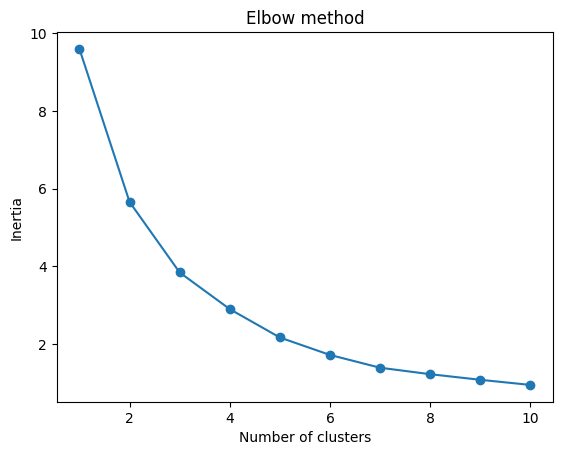

In [32]:
X = crash_df[['LATITUDE', 'LONGITUD']].values

inertias = []
for i in range(1, 11):
    # 'k-means++' is an advanced initialization method that speeds up convergence
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # Get the SSE (inertia)

# Plot the elbow method graph
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [33]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10) #

# Fit the model to the data and predict the cluster assignments
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels back to your DataFrame
crash_df['cluster_label'] = y_kmeans


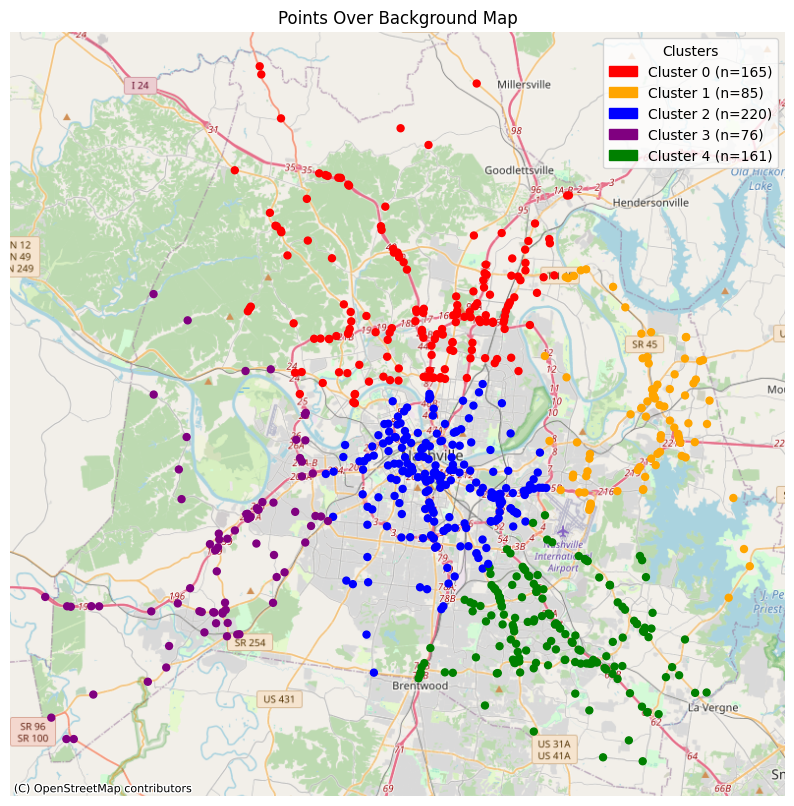

In [39]:
color_map = {
    0: "red",
    1: "orange",
    2: "blue",
    3: "purple",
    4: "green"
}

gdf = gpd.GeoDataFrame(
    crash_df,
    geometry=gpd.points_from_xy(crash_df.LONGITUD, crash_df.LATITUDE),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

gdf_web_mercator["color"] = gdf_web_mercator["cluster_label"].map(color_map)

cluster_counts = gdf_web_mercator['cluster_label'].value_counts().sort_index()

legend_handles = []

for cluster, color in color_map.items():
    count = cluster_counts.get(cluster, 0)
    label = f"Cluster {cluster} (n={count})"
    legend_handles.append(mpatches.Patch(color=color, label=label))

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(
    ax=ax,
    color=gdf_web_mercator["color"],
    markersize=25,
    legend=True)

#gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Police Stops')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend(handles=legend_handles, title="Clusters")
plt.show()

In [24]:
crash_df['cluster_label'].value_counts()

,count
cluster_label,
2,220
0,165
4,161
1,85
3,76


In [6]:
crash_df = crash_df.rename(columns={
    "LONGITUD": "lng",
    "LATITUDE": "lat"})

In [7]:
sopp_df["source"] = "police"
crash_df["source"] = "crash"
merged_df = pd.concat([sopp_df, crash_df])

In [9]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1393164 entries, 1 to 706
Data columns (total 87 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Unnamed: 0                      1393164 non-null  int64  
 1   raw_row_number                  1392457 non-null  object 
 2   date                            1392457 non-null  object 
 3   time                            1389948 non-null  object 
 4   location                        1392457 non-null  object 
 5   lat                             1393164 non-null  float64
 6   lng                             1393164 non-null  float64
 7   precinct                        1245022 non-null  object 
 8   reporting_area                  1273046 non-null  float64
 9   zone                            1245022 non-null  object 
 10  subject_age                     1392140 non-null  float64
 11  subject_race                    1391668 non-null  object 
 12  subject_s

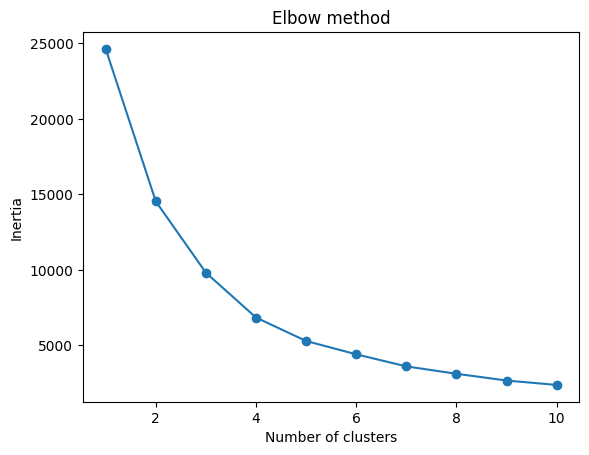

In [17]:
X = merged_df[['lat', 'lng']].values

inertias = []
for i in range(1, 11):
    # 'k-means++' is an advanced initialization method that speeds up convergence
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # Get the SSE (inertia)

# Plot the elbow method graph
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [8]:
X = merged_df[['lat', 'lng']].values

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10) #

# Fit the model to the data and predict the cluster assignments
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels back to your DataFrame
merged_df['cluster_label'] = y_kmeans


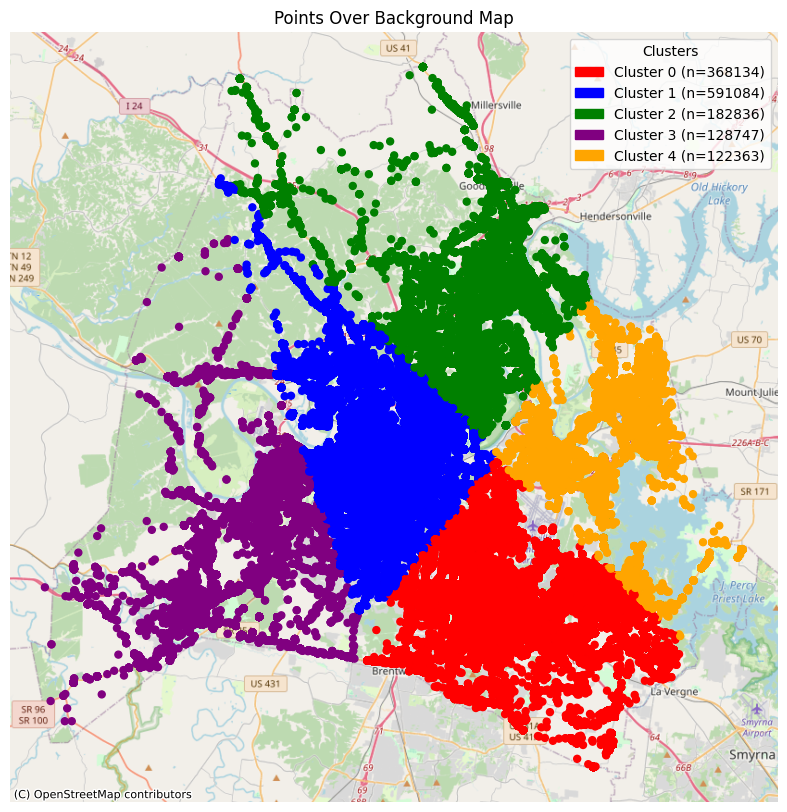

In [10]:
color_map = {
    0: "red",
    1: "blue",
    2: "green",
    3: "purple",
    4: "orange"
}

gdf = gpd.GeoDataFrame(
    merged_df,
    geometry=gpd.points_from_xy(merged_df.lng, merged_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

gdf_web_mercator["color"] = gdf_web_mercator["cluster_label"].map(color_map)

cluster_counts = gdf_web_mercator['cluster_label'].value_counts().sort_index()

legend_handles = []

for cluster, color in color_map.items():
    count = cluster_counts.get(cluster, 0)
    label = f"Cluster {cluster} (n={count})"
    legend_handles.append(mpatches.Patch(color=color, label=label))

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(
    ax=ax,
    color=gdf_web_mercator["color"],
    markersize=25,
    legend=True
)

#gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Police Stops')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend(handles=legend_handles, title="Clusters")
plt.show()

In [12]:
sopp_df = merged_df[merged_df["source"] == "police"]
crash_df = merged_df[merged_df["source"] == "crash"]

In [27]:
sopp_df.to_csv("sopp_df_3_8.csv")
crash_df.to_csv("crash_df_3_8.csv")